# LAB 1 -- DAY 3B -- CALIBRATION CURVES

We are going to use python (no, not the animal :/) to analyze and plot our data using calibration curves. For this, you take the known concentrations and measure the detector response value (height of peak) for each concentration. We will use a scatter plot to plot our data.

x-axis : concentration

y-axis : response (height/intensity)

From the graph, you will create a linear trendline which will give you the best fit slope and intercept. You can then use this to determine the concentration of any unknown by measuring the detector response and working backwards.

EXCEL TIME (for me): 16 mins 15 secs, monkeying with the graph was def the most time consuming part

pip install pandas numpy matplotlib scipy jupyter nbformat nbclient ipykernel


# What is python and how can we use it ?!

Python is a programming language that is very easy to use and capable of analyzing large data sets in a short amount of time.

A value can be a number (67, 9.11) or a string / message ("dialogue", "lowkenuinely")

Some important things to note:
* **ctrl + enter** : runs the selected code block or section instead of manually pressing *run*
* **#** : represents a comment and is used to explain the code, anything written to the right of '#' is ignored by the computer
* **ctrl + /** : quickly comment / uncomment lines of code or text
* **variable_name = value** : assigns a value or message to a variable
* **print("message")** : prints or shows message on the screen
* **print(value)** : prints variable or value inside () on the screen



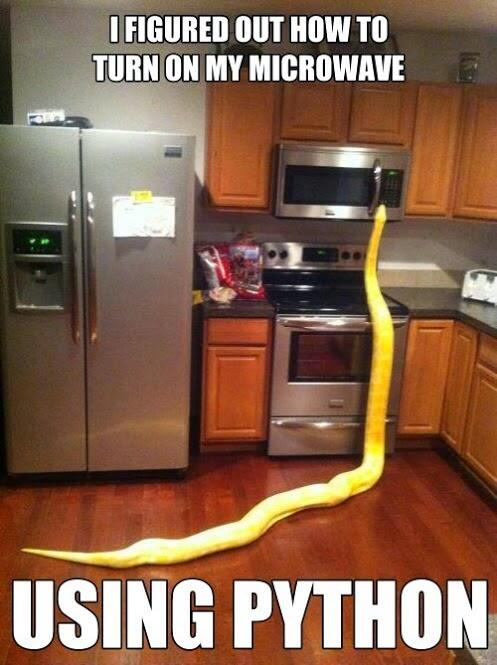

# So how do we store our data ?

To store data, you can use a list !

In python, the way we do this is: **list_name = [vaule1, value2, ..., valueN]**

For example: **tv_shows = ["squid games", "gossip girl", "avatar the last airbender"]**

In this lab, we want to store our concentration (μM) and dectector response (mV) data by using lists.

In [1]:
# this is a comment
# first step is to create lists for our two variables (conc and response)
# and put our unknown sample into a variable (unk)
conc = [0, 5, 10, 15, 20, 25]                               # concentrations (μM)
response = [-6.32, 181.63, 316.95, 449.52, 653.11, 774.3]   # detector responses (mV)
unk = 337.45                                                # unknown detector response sample (mV)

# finds the number of values in our data set
data_length = len(conc)                                     # length of conc list, can use response list too

In [2]:
# @title "conc and response" data table
# importing pandas (table and data library)
import pandas as pd

# creates a table of values using a dictionary
data = {}

# adding columns of data: data["col_title"] = col_data
data["conc"] = conc
data["response"] = response

# displays data in table like format to visually see data
df = pd.DataFrame(data)
display(df)

,conc,response
0,0,-6.32
1,5,181.63
2,10,316.95
3,15,449.52
4,20,653.11
5,25,774.30


# How do we access a specific item and add other items to a list ?

Take our tv show list example above: **tv_shows = ["squid games", "gossip girl", "avatar the last airbender"]**

To get an item on our list, we use: **list_name[index]**, where index starts at 0 and goes to (n - 1) items in the list.

* "squid games" = tv_shows[0]
* "gossip girl" = tv_shows[1]
* "avatar the last airbender" = tv_shows[2]

To add an item to the end of a list, we use: **list_name.append(value)**

For example: **tv_shows.append("american dad")**

Our new tv show list would be: **tv_shows = ["squid games", "gossip girl", "avatar the last airbender", "american dad"]**

We will use this in order to go through each response value, correct the value, and add it to a new *corrected_responses* list.


In [3]:
# at conc = 0 μM, response SHOULD equal 0 (called a blank) but ours doesn't
# to fix this, subtract response at 0 μm from response at every other value
corrected_responses = []  # creating a new list for corrected responses

# correcting each response value and adding it to our corrected_responses list
# response[0]
corrected_response0 = response[0] - response[0]
corrected_responses.append(corrected_response0)

# response[1]
corrected_response1 = response[1] - response[0]
corrected_responses.append(corrected_response1)

# response[2]
# TODO
# 1) find corrected response[2]
corrected_response2 = None
corrected_response2 = response[2] - response[0]
# 2) add corrected response to corrected_responses list
corrected_responses.append(corrected_response2)

# response[3]
corrected_response3 = response[3] - response[0]
corrected_responses.append(corrected_response3)

# response[4]
# TODO
# 1) find corrected response[4]
corrected_response4 = None
corrected_response4 = response[4] - response[0]
# 2) add corrected response to corrected_responses list
corrected_responses.append(corrected_response4)

# response[5]
corrected_response5 = response[5] - response[0]
corrected_responses.append(corrected_response5)

# OH MY that took a while, how can we make that go faster ??

Did you notice that there was only one difference in finding each response value? The only change was the index value of the response being subtracted from. We can use a 'for loop' to automate this process with A LOT less lines of code.

In [4]:
# a for loop in python looks like the following
# for i in range(length_of_list):
#   do something

# comment or uncomment the following lines of code to test the for loop
# (highlight and do 'ctrl + /' or add '#' in front of each line of code)
# these four lines of code do the exact same as the thirteen lines above
corrected_responses = []

# looping through our data_length (0 to n-1) where n=6 data items
for i in range(data_length):
  corrected = response[i] - response[0]   # calculating corrected value
  corrected_responses.append(corrected)   # adding corrected value to list

In [5]:
# don't forget to correct the unknown value too !!
# TODO
# 1) correct the unknown value
corrected_unk = None
corrected_unk = unk - response[0] # correct the unknown value

In [6]:
# @title "conc, response, and corrected" data table
# adding corrected responses to table
data["corrected"] = corrected_responses

# displays data in table like format to visually see data
df = pd.DataFrame(data)
display(df)

,conc,response,corrected
0,0,-6.32,0.00
1,5,181.63,187.95
2,10,316.95,323.27
3,15,449.52,455.84
4,20,653.11,659.43
5,25,774.30,780.62


# Now that we have the correct data, how do we plot it ?

One of the great things about python, is that you can import different libraries that other people have already created, and use them to your benefit.

Here, we are going to use the following imports:
* pandas : used to put our data into a table-like structure (used above for creating the data tables)
* matplotlib.pyplot : used to create and beautify the scatter plot
* numpy : changes our lists into arrays that can be used to graph the data
* scipy -> stats : used to find the slope, y-intercept, and r-value using linear regression

Note:
* if one of the imports doesn't work, you can use: **!pip install package_name**
* for example: **!pip install numpy**

In [7]:
# importing matplotlib, numpy, and stats libraries
import matplotlib.pyplot as plt     # use plt to access matplotlib.pylot functions
import numpy as np                  # use np to access numpy functions
import scipy.stats as stats         # use stats to access the scipy.stats functions

# remember --> x-axis : conc , y-axis : corrected_responses

# first, we need to use np.array() on conc and corrected_responses lists so we can use them to plot our data
# for example z = np.array(cacti_list)
# TODO
# 1) create 'x' np array
x_array = None
x_array = np.array(conc)                  # create 'x' np array
# 2) create 'y' np array
y_array = None
y_array = np.array(corrected_responses)   # create 'y' np array

# Next, the fun part - creating and plotting our data !!

1) create the scatter plot
2) calculate the slope, y-intercept, and r-value from the linear regression
3) plot the trendline
4) add the trendline and r^2 equations on the graph
5) customize your graph with titles
6) show final plot

Note: you will only need to know how to do step 5 (customizing your graph). You can also customize the color of the trendline in step 3.

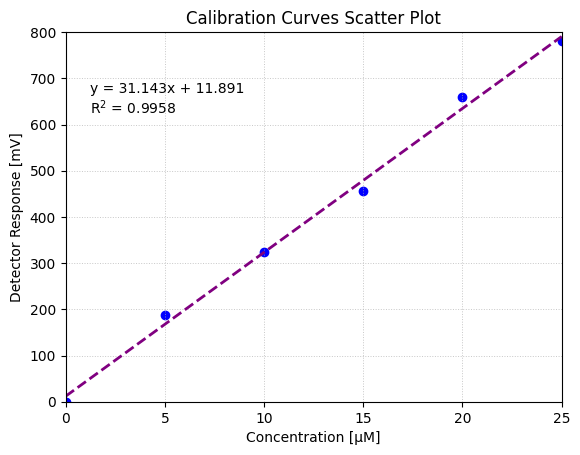

slope = 31.143485714285717
y-intercept = 11.891428571428548


In [8]:
# 1. creating the scatter plot
plt.scatter(x_array, y_array, color="blue")

# 2. calculating the variables for the trendline
# you will only need the slope (m), y-intercept (b), and r-value (r)
# you can ignore the p-value (p) and standard error (stderr)
m, b, r, p, stderr = stats.linregress(x_array, y_array)

# 3. plotting the trendline
# feel free to change the color of the trendline by swapping 'red' for '<color of your choice>'
plt.plot(
    x_array, m*x_array + b,          # x and y values for trendline, don't change this

    # --- customizable --- #
    color='purple',                     # color of trendline
    linestyle='--',                  # line style: '--', '-.', ':', '-'
    linewidth=2                      # line width
)

# 4. adding trendline and r^2 equations to graph
trendline_string = (
    f"y = {m:.3f}x + {b:.3f}\n"   # {var:.3f} : uses value of var and shows first 3 decimal places
    f"R$^2$ = {r**2:.4f}"         # R$^2$ : LaTeX math so Matplotlib displays R² nicely, {r**2:.4f} : R^2 with 4 decimal places
)
plt.annotate(trendline_string, xy=(0.14, 0.71), xycoords="figure fraction")  # position is 14% from the left and 71% from the bottom of the *entire figure* 

# 5. customizing graph with titles
# use plt.title("title") to add a title
# use plt.xlabel("label") for x axis and plt.ylabel("label") for y axis
# TODO
# 1) add title of graph
plt.title("Calibration Curves Scatter Plot")                                 # add title of graph
# 2) label x axis
plt.xlabel("Concentration [μM]")                                            # label x axis
# 3) label y axis
plt.ylabel("Detector Response [mV]")                                        # label y axis

plt.xlim(0, 25)
plt.ylim(0, 800)
plt.grid(True, linestyle=':', linewidth=0.7, alpha=0.7) 

# 6. showing scatter plot
plt.show()

# printing full slope and y-intercept values
print("slope =", m)
print("y-intercept =", b)

# Having fun yet?

Going back to our unknown detector response sample (mV), how do we find the concentration (μM) using the trendline we just created?

y = m*x + b

We have the slope (m), y-intercept (b), and our unknown detector response sample (y). Using algebra, we are going to find the concentration (x) for that sample.

Note: we used the variable 'x' above to create our np array. Giving 'x' a new value updates it so we can use the variable again.

In [9]:
# rearrange the trendline equation to find the concentration (x)
# remember to use the corrected value for the unknown (y)
# TODO
# 1) solve for the value of x using the right variables / values
x = None
x = (corrected_unk - b) / m   # finding x value using x = (y-b)/m

# prints the concentration value, x
print(x)

10.656436292111534


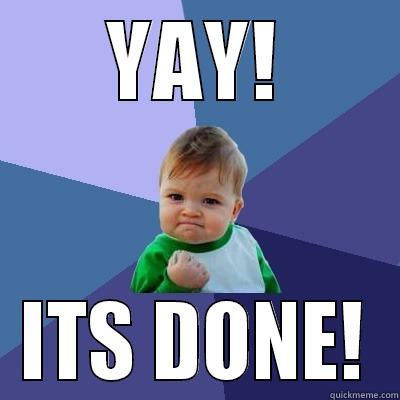